# Sensitivity test

In [1]:
from utils import cost_params
from utils import read_nc_data, calc_diff
from visualizations import create_lineplot, create_heatmap

import json
import pypsa
import logging
logging.getLogger('pypsa').setLevel(logging.ERROR)

data_path = "data/sensitivity_test/v2/"
fig_path = "figures/08_sensitivity_test/"

In [2]:
baseline = pypsa.Network(data_path+'baseline_1.nc')
baseline.generators.p_nom_opt.abs()

name
Solar                     909.086434
Wind Offshore               0.000000
Wind Onshore             2000.000000
Hydro Run-of-river         36.000000
Hydro Water Reservoir      28.000000
Geothermal                  0.000000
Biomass                     0.000000
Waste                     300.000000
Fossil Lignite            227.053694
Fossil Hard coal            0.000000
Fossil Gas                  0.000000
Nuclear                  2775.793673
Fusion                      0.000000
Name: p_nom_opt, dtype: float64

----
# Capital costs

In [3]:
cap, cap_normed = read_nc_data(data_path+'capital/*.nc', baseline)
cap_diff, cap_limits = calc_diff(cap)

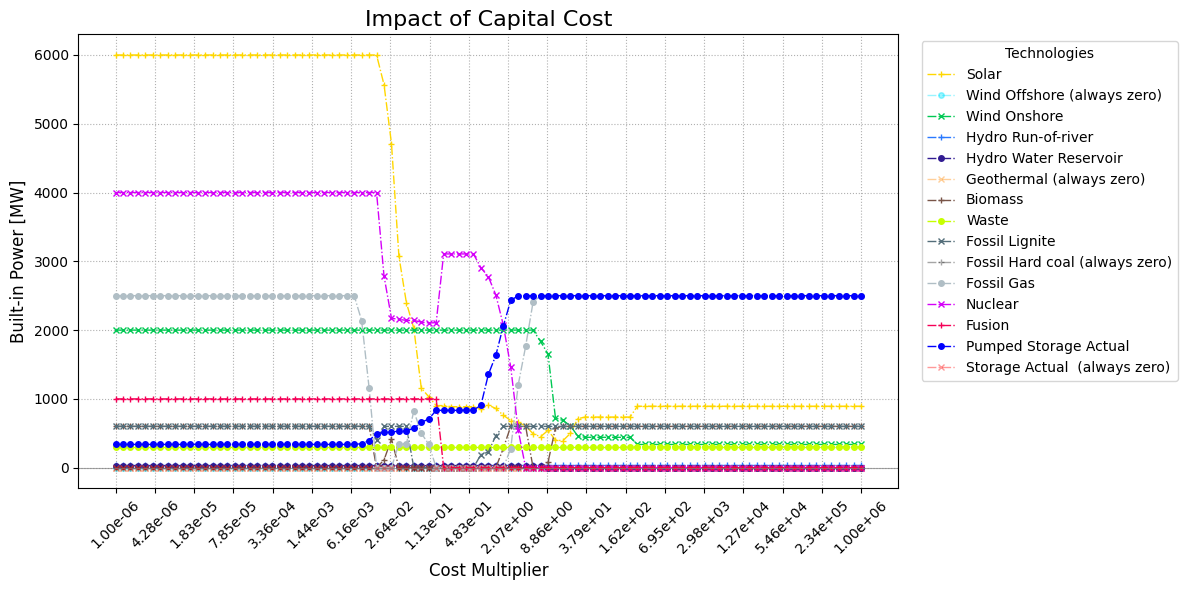

In [4]:
create_lineplot(cap, title='Capital', savefig=fig_path+'capital.png')

Boundaries: [0.009120;251.188643]


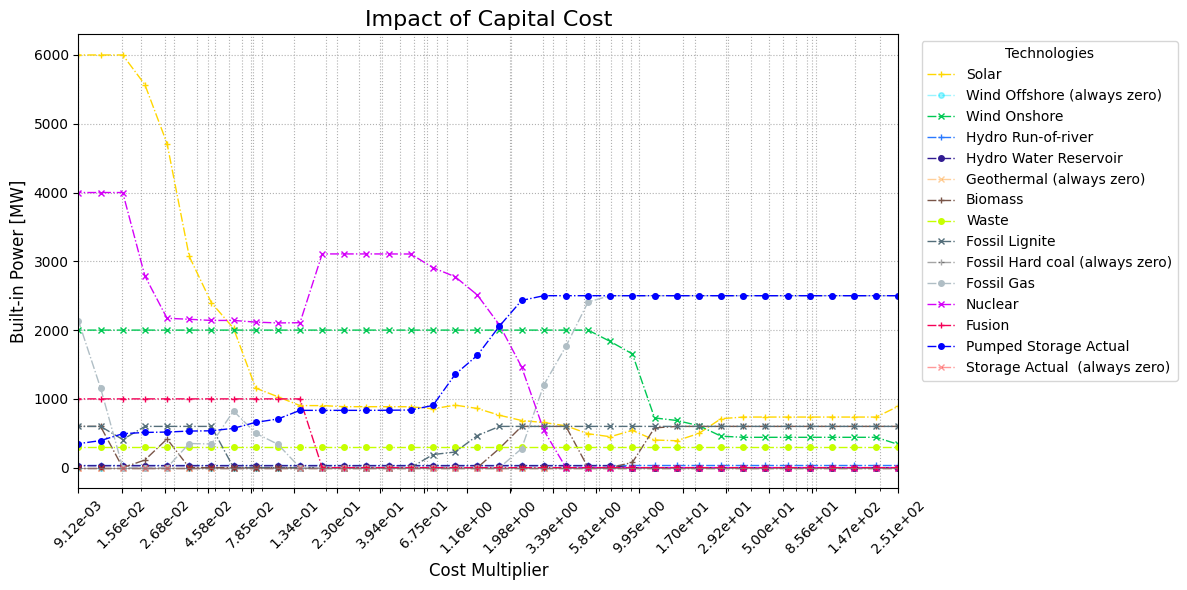

In [5]:
create_lineplot(cap, title='Capital', xlim=cap_limits, savefig=fig_path+'capital_zoom.png')

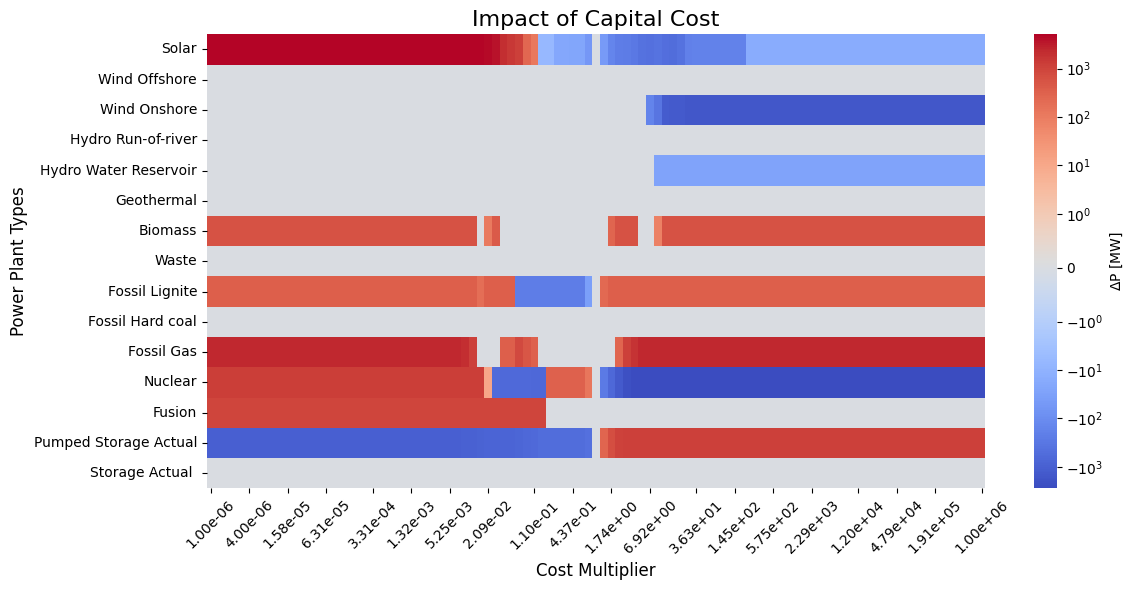

In [6]:
create_heatmap(cap_normed, title='Capital', savefig=fig_path+'capital_hmap.png')

---
# Environmental costs

In [7]:
env, env_normed = read_nc_data(data_path+'environment/*.nc', baseline)
env_diff, env_limits = calc_diff(env)

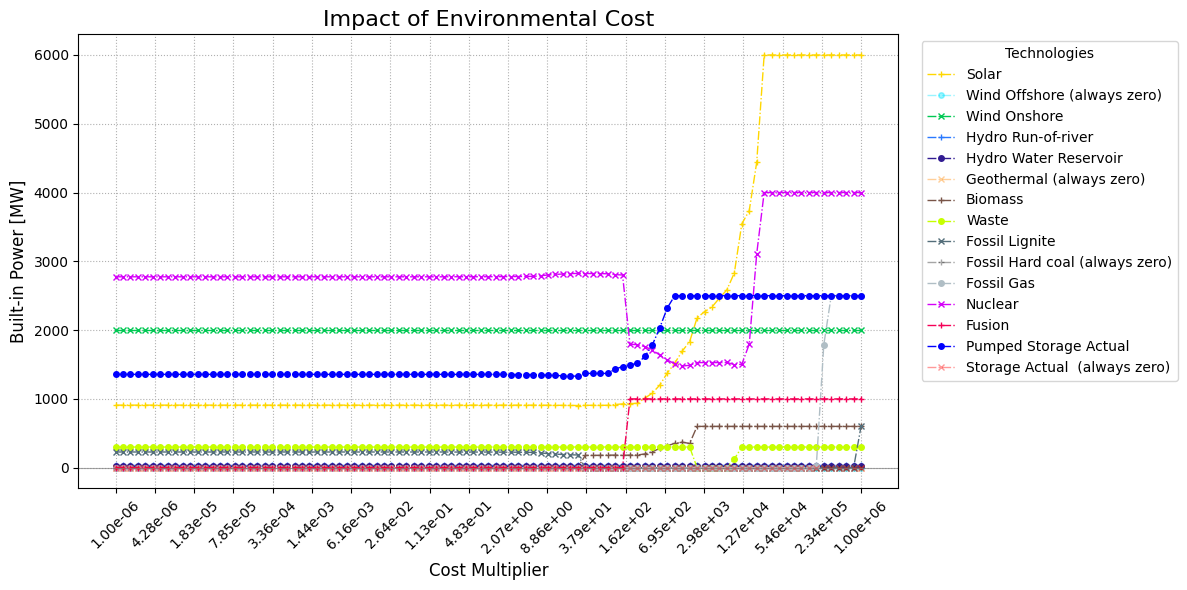

In [8]:
create_lineplot(env, title='Environmental', savefig=fig_path+'environment.png')

Boundaries: [6.918310;1000000.000000]


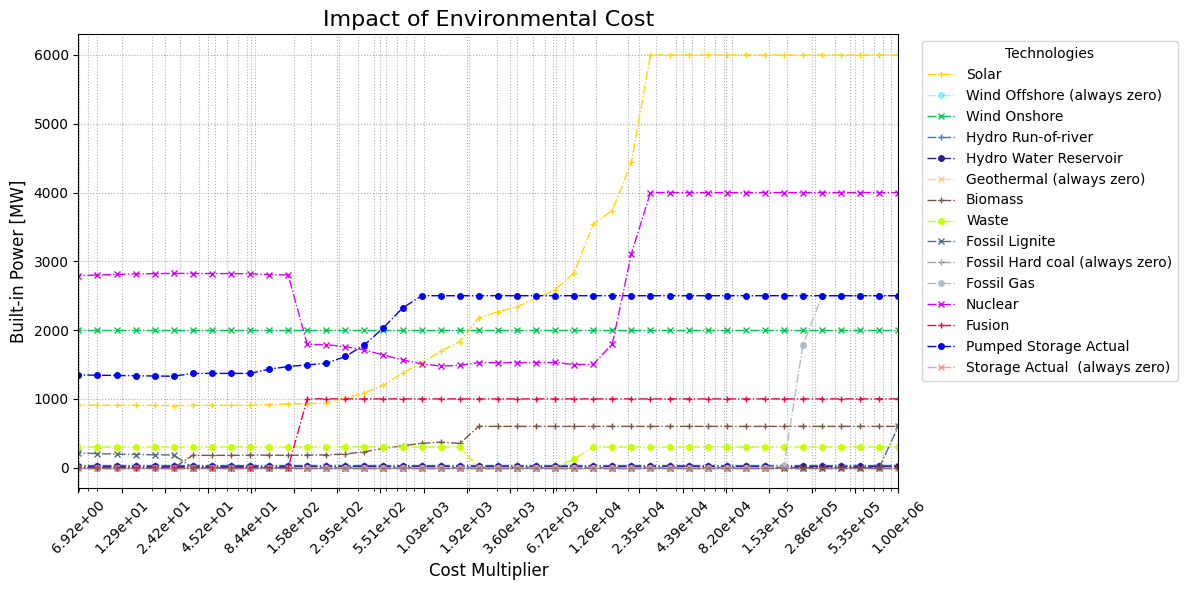

In [9]:
create_lineplot(env, title='Environmental', xlim=env_limits, savefig=fig_path+'environment_zoom.png')

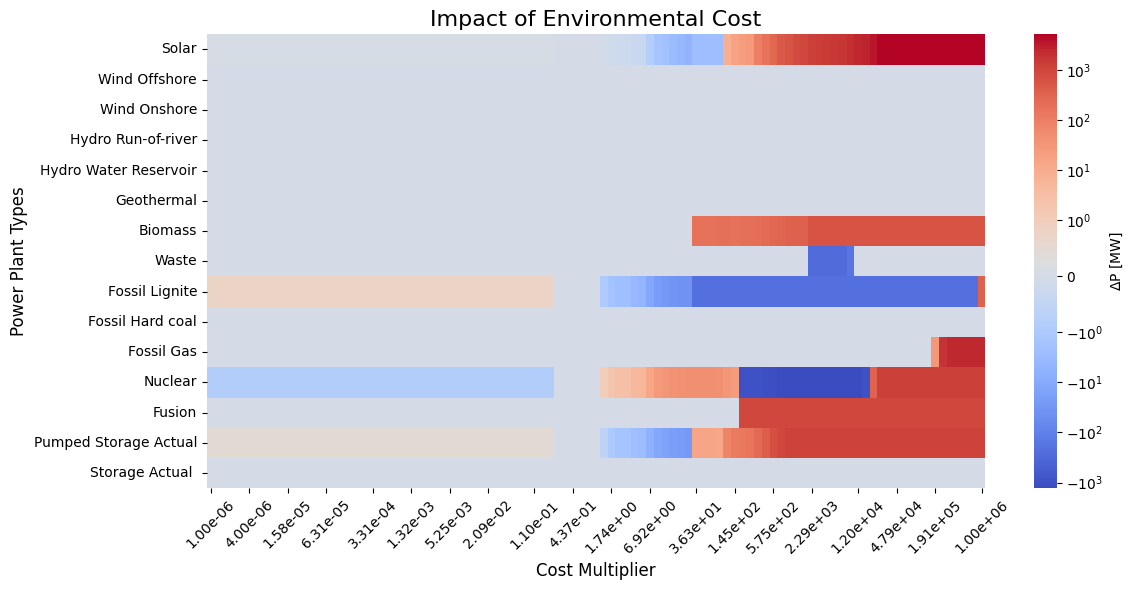

In [10]:
create_heatmap(env_normed, title='Environmental', savefig=fig_path+'environment_hmap.png')

----
# Operational costs

In [11]:
op, op_normed = read_nc_data(data_path+'operation/*.nc', baseline)
op_diff, op_limits = calc_diff(op)

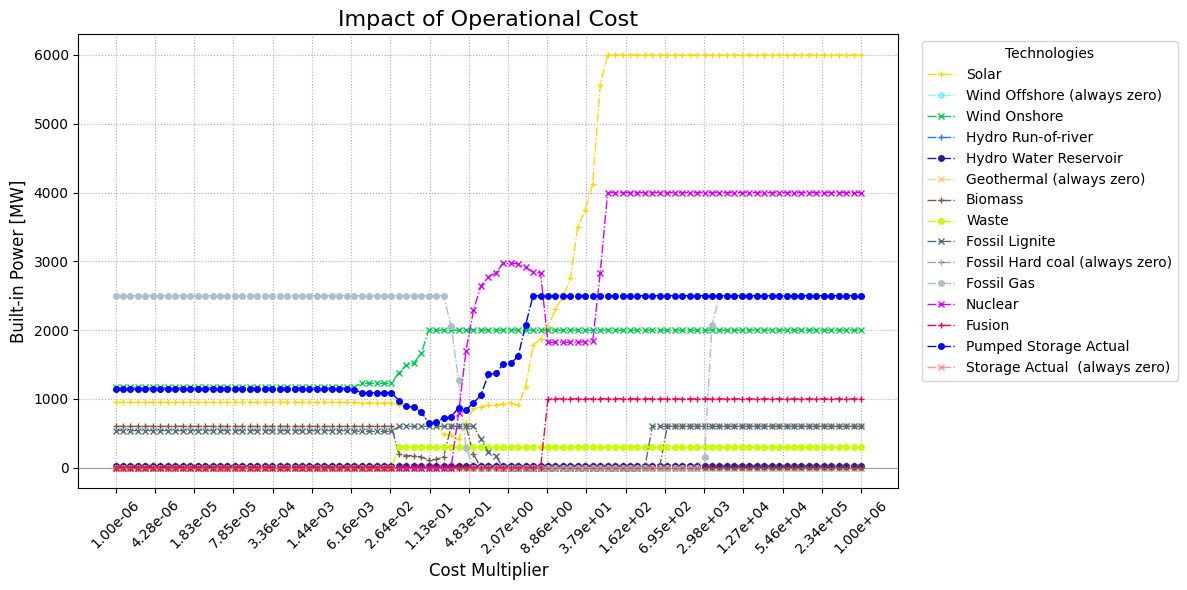

In [12]:
create_lineplot(op, title='Operational', savefig=fig_path+'operation.png')

Boundaries: [0.006918;5248.074602]


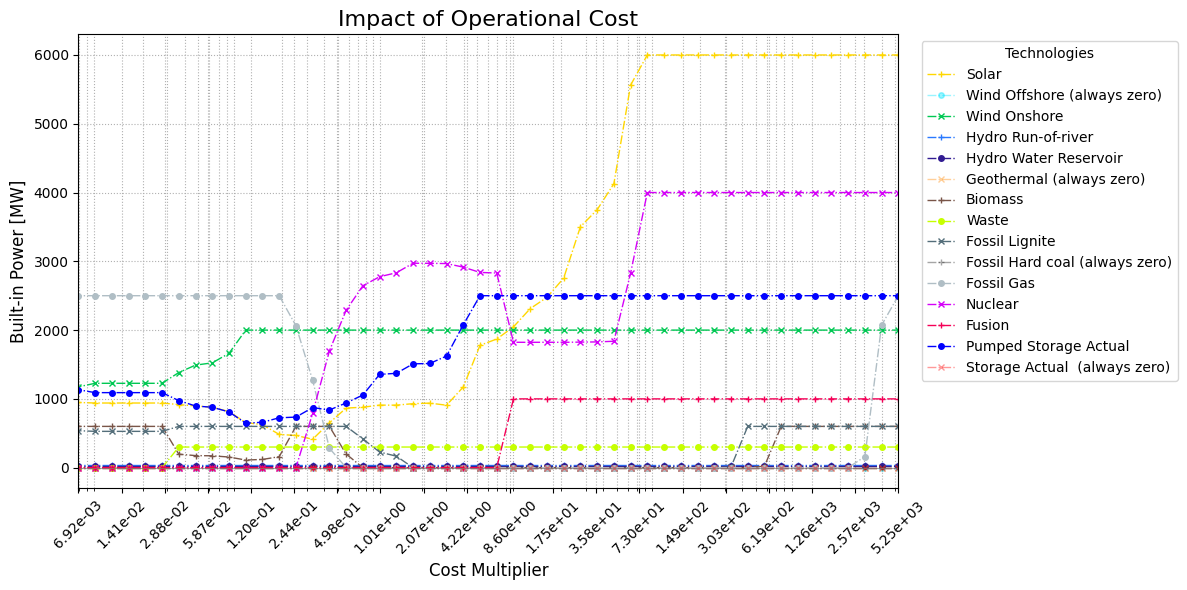

In [13]:
create_lineplot(op, title='Operational', xlim=op_limits, savefig=fig_path+'operation_zoom.png')

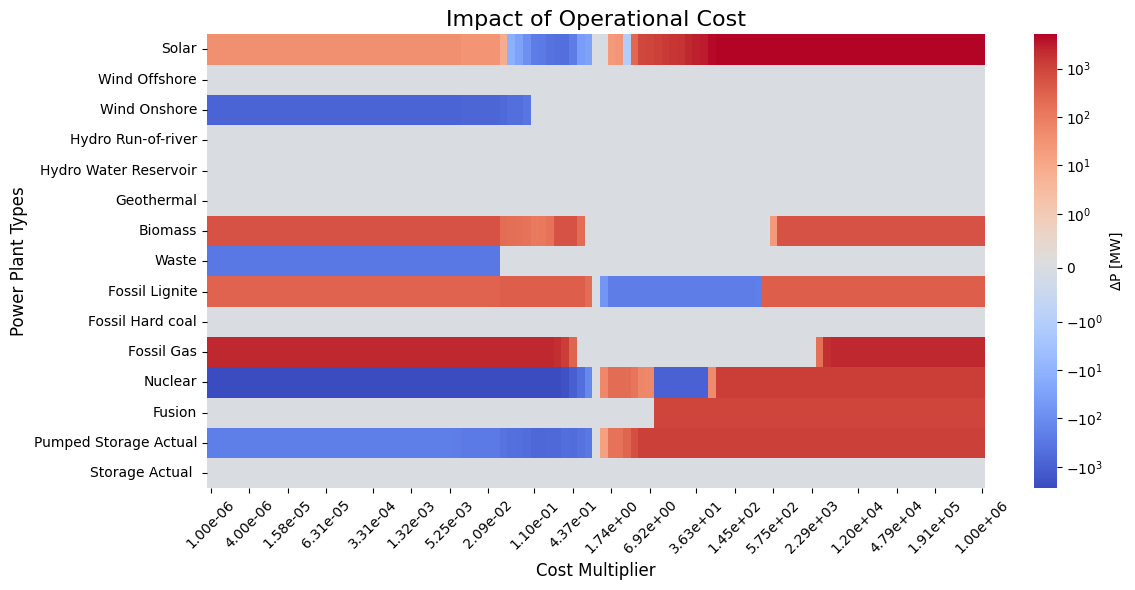

In [14]:
create_heatmap(op_normed, title='Operational', savefig=fig_path+'operation_hmap.png')

----
# Reliability costs

In [15]:
rel, rel_normed = read_nc_data(data_path+'reliability/*.nc', baseline)
rel_diff, rel_limits = calc_diff(rel, min_diff=1)

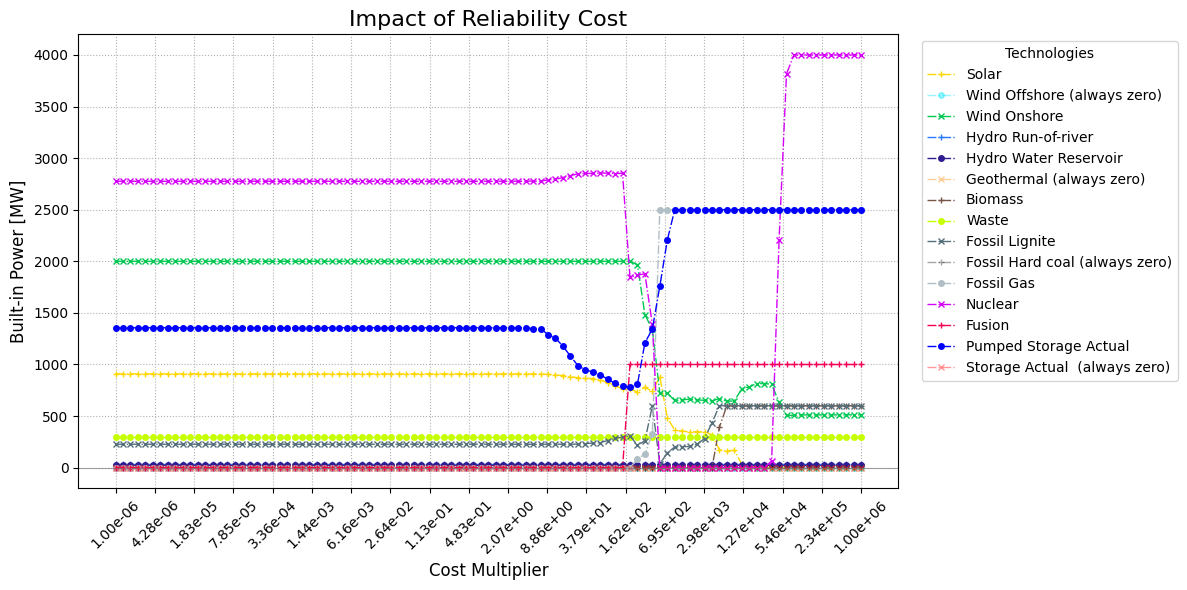

In [16]:
create_lineplot(rel, title='Reliability', savefig=fig_path+'reliability.png')

Boundaries: [3.019952;109647.819614]


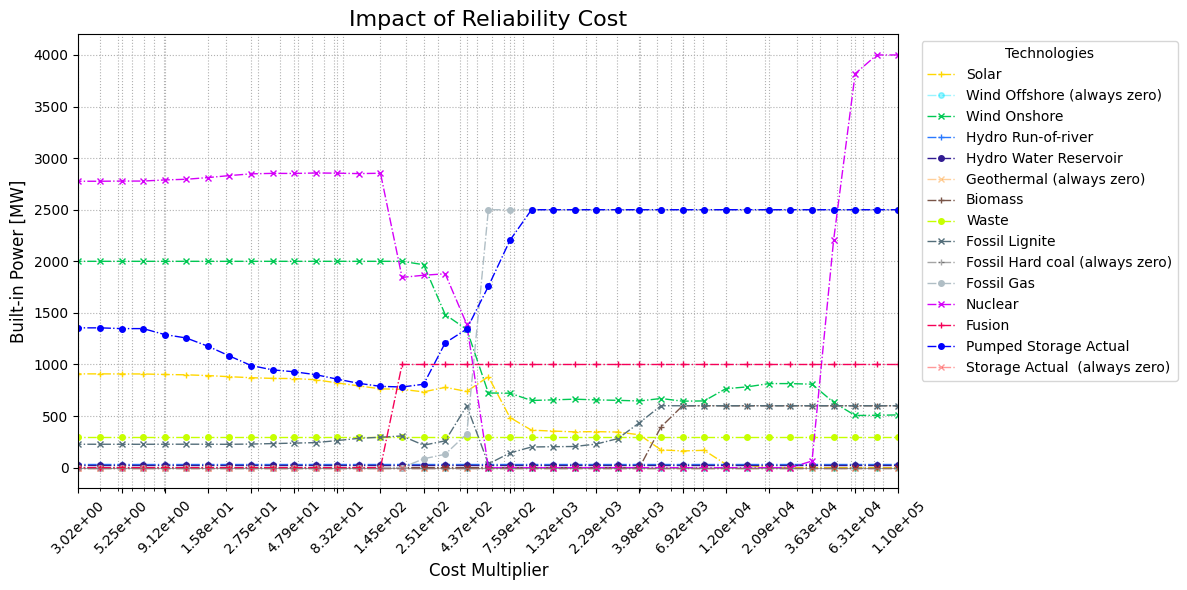

In [17]:
create_lineplot(rel, title='Reliability', xlim=rel_limits, savefig=fig_path+'reliability_zoom.png')

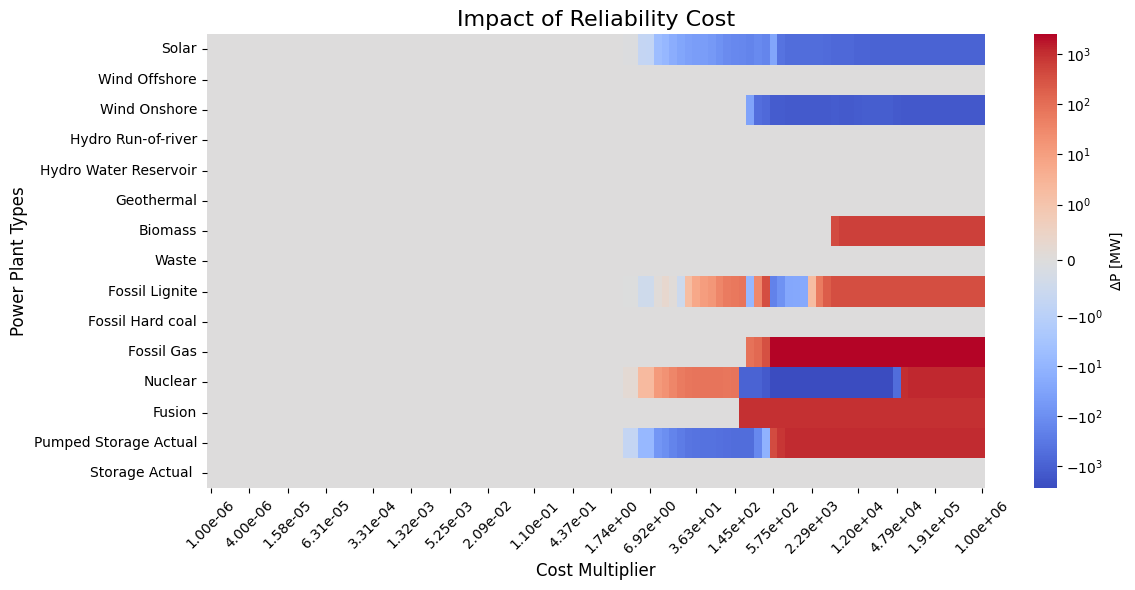

In [18]:
create_heatmap(rel_normed, title='Reliability', savefig=fig_path+'reliability_hmap.png')

----
# Risk costs

In [19]:
risk, risk_normed = read_nc_data(data_path+'risk/*.nc', baseline)
risk_diff, risk_limits = calc_diff(risk)

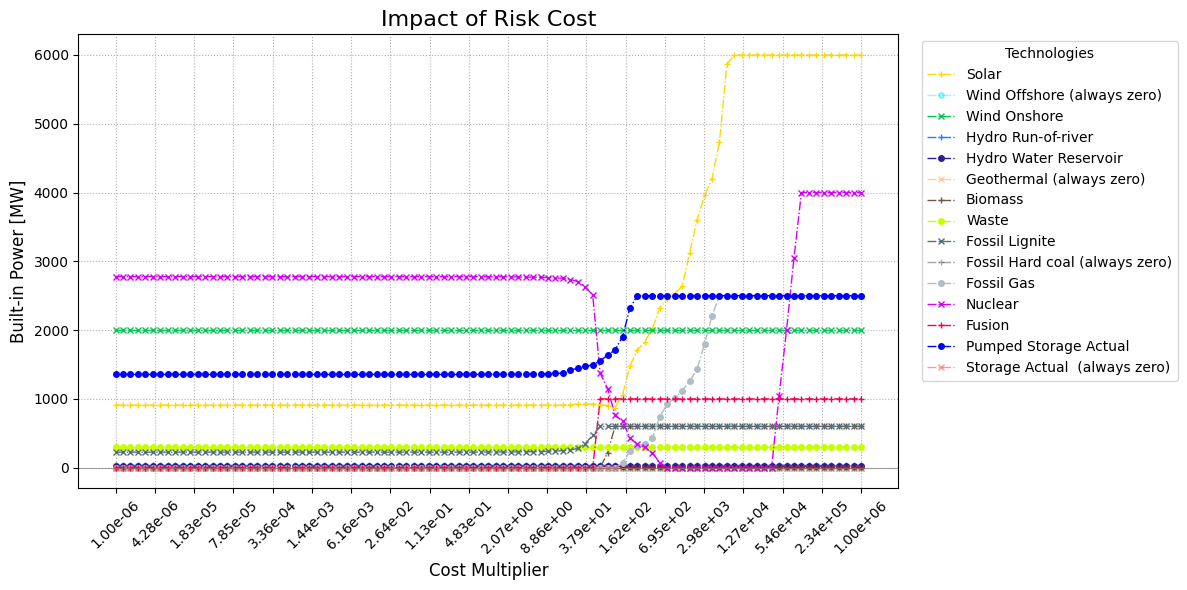

In [20]:
create_lineplot(risk, title='Risk', savefig=fig_path+'risk.png')

Boundaries: [9.120108;109647.819614]


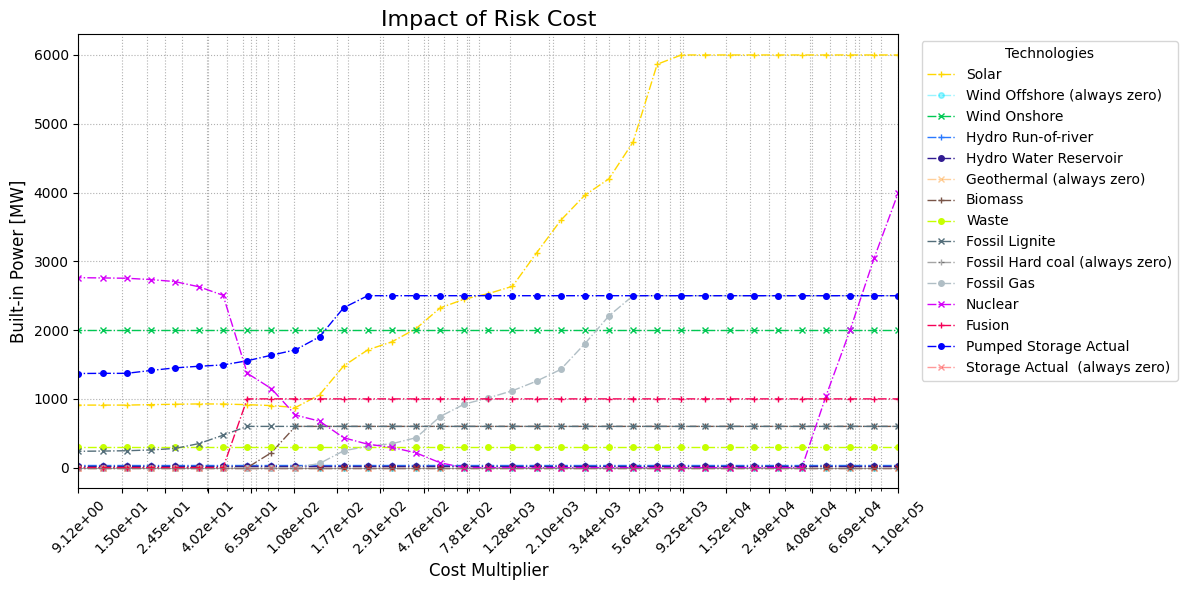

In [21]:
create_lineplot(risk, title='Risk', xlim=risk_limits, savefig=fig_path+'risk_zoom.png')

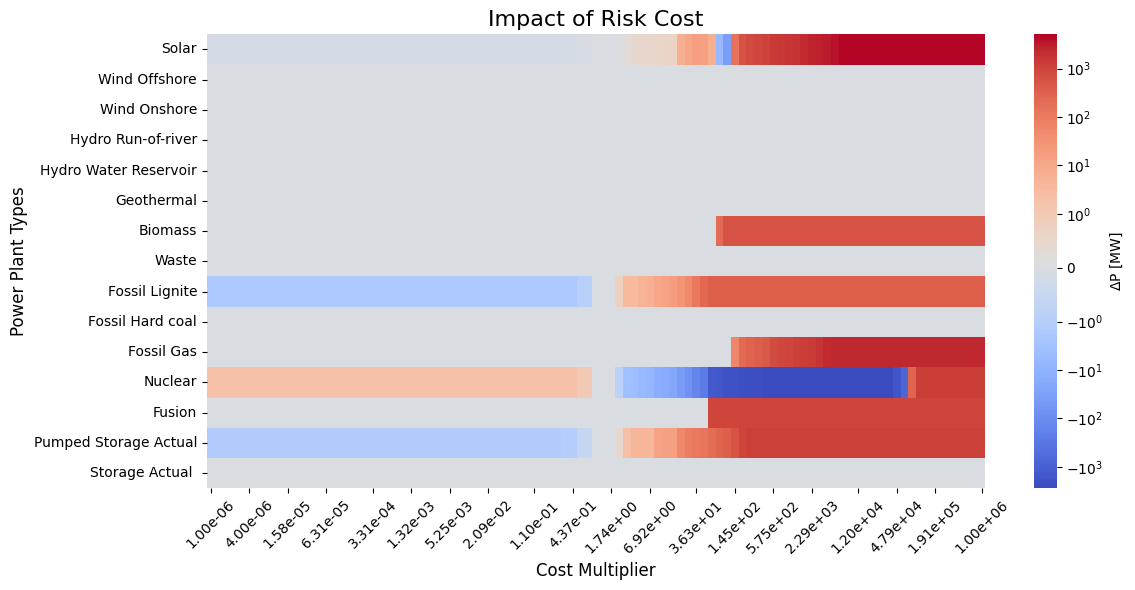

In [22]:
create_heatmap(risk_normed, title='Risk', savefig=fig_path+'risk_hmap.png')

---
# Save cost limits

In [23]:
cost_boundaries = {}
limits = [cap_limits, env_limits, op_limits, rel_limits, risk_limits]
for i, cp in enumerate(cost_params):
    cost_boundaries[cp]=limits[i].to_list()
with open("data/sensitivity_test/cost_boundaries.json", "w") as f:
    json.dump(cost_boundaries, f, indent=4)